# RL “for dummies” en tu PC: entrenar y **ver** un agente jugando (sin dramas de librerías)

Objetivo: en **15–20 min** tener un agente que “juega” a **CartPole** (equilibrar un palo) y poder:
- **Entrenarlo rápido** (PPO con Stable-Baselines3)
- **Verlo en un GIF** dentro del notebook
- **Guardar / cargar** el modelo (agente “ya entrenado”)
- (Opcional) **Descargar un modelo ya entrenado** desde Hugging Face y verlo jugar **sin entrenar nada**

> 🕹️ ¿Por qué no *Contra*?  
*Contra* (y retro-consolas tipo SNES/Genesis) normalmente se hace con **gym-retro / emuladores**, que lleva años sin mantenimiento y suele dar guerra en instalaciones modernas. Mejor para una demo “rápida y segura” usar **Gymnasium + Stable-Baselines3** con entornos mantenidos (CartPole / Atari ALE).

---

## 0) Requisitos y “qué instalar” (lo más importante para que no te explote nada)

### Requisitos mínimos
- Python **3.8+** (recomendado 3.10/3.11)
- En Windows suele ser más cómodo con **Conda/Anaconda**.

### Instalar lo necesario (recomendado)
Ejecuta **una** de estas opciones (en una celda con `!` o en tu terminal):

**Opción A (demo CartPole + render + gráficos):**
- `gymnasium[classic-control]` asegura dependencias de Classic Control (CartPole) y su render.
- `stable-baselines3[extra]` instala SB3 y extras útiles.

**Opción B (si SOLO quieres el modelo preentrenado desde Hugging Face):**
- añade `huggingface-sb3` (para `load_from_hub`).

### Nota importante sobre Atari (deprecaciones / cambios recientes)
- Los Atari modernos suelen estar en el namespace **`ALE/...-v5`** (por ejemplo `ALE/Pong-v5`).
- La instalación de ROMs/Atari ha cambiado con Gymnasium: en versiones recientes basta con `gymnasium[atari]`, y a veces hay que hacer `import ale_py` antes de `gym.make`. Si tu setup es antiguo, puede aparecer la variante `gymnasium[atari,accept-rom-license]`.

En este notebook nos centramos en **CartPole** (cero ROMs) + un **bonus Atari** opcional.

In [1]:
# Si estás en Jupyter / VSCode Notebook, puedes ejecutar esto aquí mismo:
# (si lo ejecutas en terminal, quita el "!" de delante)

# Demo principal (CartPole):
# !pip -q install "gymnasium[classic-control]" "stable-baselines3[extra]" "imageio" "matplotlib" "pandas"

# Para cargar un modelo YA entrenado desde Hugging Face (opcional):
# !pip -q install "huggingface-sb3" "huggingface_hub"

---

## 1) Imports + comprobaciones rápidas

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy

import imageio.v2 as imageio
from IPython.display import Image, display

print("Gymnasium:", gym.__version__)

Gymnasium: 1.2.3


---

## 2) Entorno: CartPole-v1 (¿qué es esto?)

**CartPole** = un carrito con un palo.  
Acciones: empujar a izquierda o derecha.  
Objetivo: que el palo no caiga.

Esto es perfecto para una demo porque:
- se entrena rápido,
- no hay ROMs,
- no hay dependencias raras (más allá de pygame/render, que cubrimos con `gymnasium[classic-control]`).

In [ ]:
env_id = "CartPole-v1"
env = gym.make(env_id)  # sin render por ahora

obs, info = env.reset()
print("Observación inicial:", obs)
print("Dim obs:", env.observation_space)
print("Acciones:", env.action_space)

env.close()

Observación inicial: [-0.0373068  -0.04589851  0.01085811 -0.01296641]
Dim obs: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Acciones: Discrete(2)


---

## 3) (Opción 1) Entrenar un agente rápido (PPO) y ver que mejora

Vamos a:
1. Crear un entorno con **Monitor** para registrar recompensas
2. Entrenar PPO unos pasos (ajustable)
3. Evaluar el agente

In [ ]:
# Carpeta de logs para poder dibujar una curva de aprendizaje simple
log_dir = Path("logs_cartpole")
log_dir.mkdir(exist_ok=True)

# Entorno con Monitor (guarda episodios/recompensas en un CSV)
train_env = gym.make(env_id)
train_env = Monitor(train_env, filename=str(log_dir / "monitor.csv"))

# Modelo PPO (red neuronal pequeña por defecto)
model_0 = PPO(
    policy="MlpPolicy",
    env=train_env,
    verbose=1,
    seed=0,
)


Using cpu device
Wrapping the env in a DummyVecEnv.


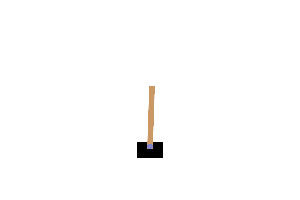

In [ ]:
import numpy as np
import gymnasium as gym
import imageio.v2 as imageio

def record_episode_to_gif(
    model,
    env_id="CartPole-v1",
    gif_path="agent.gif",
    max_steps=2000,
    fps=20,          # menos fps = menos frames por segundo
    every=2,         # guarda 1 de cada 'every' frames (2 => la mitad)
    downsample=2,    # 2 => mitad ancho/alto (mucho menos peso)
):
    env = gym.make(env_id, render_mode="rgb_array")
    obs, info = env.reset()

    writer = imageio.get_writer(gif_path, mode="I", fps=fps, loop=0)

    try:
        for t in range(max_steps):
            # Renderizamos y guardamos solo cada N frames
            if t % every == 0:
                frame = env.render()

                # Downsample rápido sin dependencias extra
                if downsample and downsample > 1:
                    frame = frame[::downsample, ::downsample, :]

                writer.append_data(frame)

            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)

            if terminated or truncated:
                # último frame (opcional)
                frame = env.render()
                if downsample and downsample > 1:
                    frame = frame[::downsample, ::downsample, :]
                writer.append_data(frame)
                break
    finally:
        writer.close()
        env.close()

    return gif_path

gif_file = record_episode_to_gif(model_0, env_id=env_id, gif_path="cartpole_trained.gif")
display(Image(filename=gif_file))


In [ ]:

# Entorno con Monitor (guarda episodios/recompensas en un CSV)
train_env = gym.make(env_id)
train_env = Monitor(train_env, filename=str(log_dir / "monitor.csv"))

# Modelo PPO (red neuronal pequeña por defecto)
model = PPO(
    policy="MlpPolicy",
    env=train_env,
    verbose=1,
    seed=0,
)

# Entrenamiento rápido: prueba 30_000 ~ 100_000 timesteps
# (CartPole suele aprender bastante pronto)
total_timesteps = 50_000
model.learn(total_timesteps=total_timesteps)

# Guardamos el modelo entrenado
model_path = "ppo_cartpole_demo.zip"
model.save(model_path)

train_env.close()
print("✅ Entrenado y guardado:", model_path)

Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 25.7     |
|    ep_rew_mean     | 25.7     |
| time/              |          |
|    fps             | 2713     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 29.9        |
|    ep_rew_mean          | 29.9        |
| time/                   |             |
|    fps                  | 1895        |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.007937553 |
|    clip_fraction        | 0.0963      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.686      |
|    explained_varia

### Evaluación rápida

Evaluamos 10 episodios y vemos la recompensa media.
En CartPole, **500** es “perfecto” (límite típico).

In [28]:
eval_env = gym.make(env_id)
mean_reward, std_reward = evaluate_policy(
    model, eval_env, n_eval_episodes=10, deterministic=True
)

print(f"Mean reward: {mean_reward:.1f} +/- {std_reward:.1f}")
eval_env.close()

c:\Users\Ort\.conda\envs\rl_env\Lib\site-packages\stable_baselines3\common\evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Mean reward: 500.0 +/- 0.0


### Curva de aprendizaje (muy simple)

Leemos el `monitor.csv` y dibujamos recompensa por episodio.

      r   l         t
0  25.0  25  0.042524
1  55.0  55  0.068517
2  14.0  14  0.073517
3  26.0  26  0.083516
4  14.0  14  0.088517


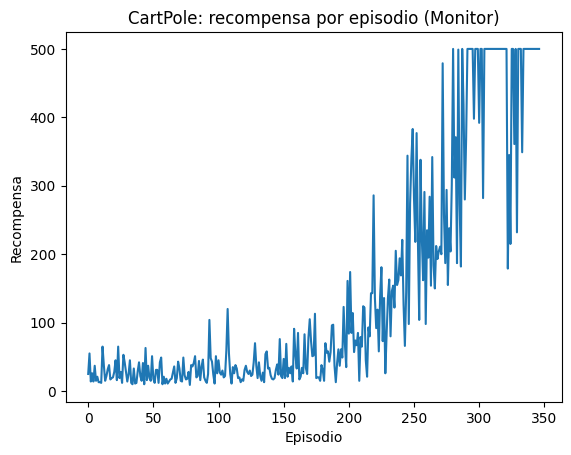

In [29]:
# El monitor de Gymnasium/SB3 añade líneas comentadas al inicio; hay que saltarlas
monitor_file = log_dir / "monitor.csv"

with open(monitor_file, "r", encoding="utf-8") as f:
    lines = f.readlines()

# Encuentra la primera línea que NO empieza por '#'
start_idx = 0
for i, line in enumerate(lines):
    if not line.startswith("#"):
        start_idx = i
        break

df = pd.read_csv(monitor_file, skiprows=start_idx)
# Columnas típicas: r (reward), l (length), t (time)
print(df.head())

plt.figure()
plt.plot(df["r"].values)
plt.xlabel("Episodio")
plt.ylabel("Recompensa")
plt.title("CartPole: recompensa por episodio (Monitor)")
plt.show()

---

## 4) Ver al agente “jugar” dentro del notebook (GIF)

En vez de abrir una ventana (que a veces da problemas en notebooks), usamos `render_mode="rgb_array"` para capturar frames.

> Si quieres ventana “real”, en local puedes usar `render_mode="human"` (lo pongo en el bonus de troubleshooting).

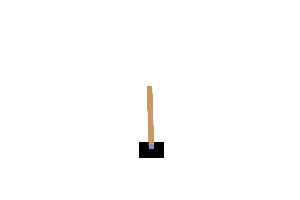

In [37]:


gif_file = record_episode_to_gif(model, env_id=env_id, gif_path="cartpole_trained.gif")
display(Image(filename=gif_file))

---

## 5) Cargar el modelo “ya entrenado” (local) y volver a verlo jugar

Esto simula el caso típico: **entrené ayer, hoy solo quiero verlo funcionar**.

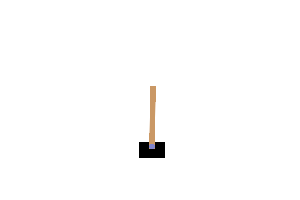

In [38]:
loaded_model = PPO.load(model_path)

gif_file2 = record_episode_to_gif(loaded_model, env_id=env_id, gif_path="cartpole_loaded.gif")
display(Image(filename=gif_file2))

---

## 6) (Opción 2) Cargar un modelo YA entrenado de internet (Hugging Face)

Si quieres una demo **instantánea**, puedes bajar un modelo preentrenado del Hub (sin entrenar nada).

Ejemplo típico:
- repo: `sb3/ppo-CartPole-v1`
- archivo: `ppo-CartPole-v1.zip`

> Si estás sin internet, salta esta sección.

c:\Users\Ort\.conda\envs\rl_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
c:\Users\Ort\.conda\envs\rl_env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Ort\.cache\huggingface\hub\models--sb3--ppo-CartPole-v1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more d

[HF] Mean reward: 500.0 +/- 0.0


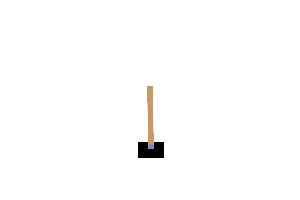

In [39]:
from huggingface_sb3 import load_from_hub

# Descarga el zip del modelo desde Hugging Face
checkpoint = load_from_hub(
    repo_id="sb3/ppo-CartPole-v1",
    filename="ppo-CartPole-v1.zip",
)

hf_model = PPO.load(checkpoint)

# Evaluamos y vemos en GIF
eval_env = gym.make(env_id)
mean_reward, std_reward = evaluate_policy(hf_model, eval_env, n_eval_episodes=10, deterministic=True)
eval_env.close()
print(f"[HF] Mean reward: {mean_reward:.1f} +/- {std_reward:.1f}")

gif_file3 = record_episode_to_gif(hf_model, env_id=env_id, gif_path="cartpole_hf.gif")
display(Image(filename=gif_file3))

---

## 7) Bonus (opcional): Atari Pong (si quieres “juego clásico” tipo arcade)

**Ojo:** Atari requiere dependencias extra y, según versiones, puede requerir:
- `pip install "gymnasium[atari]"`  (más reciente)
- y/o `import ale_py` antes de crear el env
- en setups antiguos: `gymnasium[atari,accept-rom-license]`

Si te interesa, prueba esto:

1) Instala Atari:
- `pip install "gymnasium[atari]"`

2) Luego ejecuta el código de abajo para **ver 200 pasos de un agente aleatorio** (solo para comprobar que funciona).

> Entrenar Pong “de verdad” no es rápido (no es una demo de 5 minutos), por eso aquí solo hacemos “smoke test”.

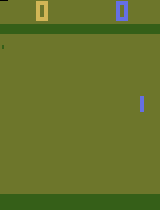

In [41]:
# DESCOMENTA para instalar Atari si quieres probarlo.
# !pip -q install "gymnasium[atari]"

# En algunas versiones recientes, se recomienda importar ale_py antes de gym.make:
import ale_py  # noqa: F401

# Descomenta para probar:
atari_env_id = "ALE/Pong-v5"
env = gym.make(atari_env_id, render_mode="rgb_array")
obs, info = env.reset()
frames = []
for _ in range(200):
    frames.append(env.render())
    action = env.action_space.sample()  # agente aleatorio
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        obs, info = env.reset()
env.close()
imageio.mimsave("pong_random.gif", frames, fps=30)
display(Image(filename="pong_random.gif"))

---

## 8) Troubleshooting rápido (las 4 cosas que más fallan)

1) **`No module named pygame` / render no funciona**  
   Instala: `pip install "gymnasium[classic-control]"` (incluye deps de render de Classic Control)

2) **En notebook no aparece una ventana aunque pongas `render_mode="human"`**  
   Es normal según el frontend. Usa el enfoque de este NB: `render_mode="rgb_array"` + GIF.

3) **Atari no crea el entorno (`ALE/...` no encontrado)**  
   Asegúrate de instalar el extra y, en algunas versiones recientes, hacer `import ale_py` antes de `gym.make`.

4) **Quieres “Contra”/retro SNES**  
   Es posible, pero normalmente implica **gym-retro / emulación**, y en 2025–2026 suele estar poco mantenido y dar guerra. Para una clase/demostración rápida: mejor CartPole o Atari ALE.

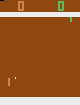

In [45]:
# === PONG (ALE/Pong-v5) === Entrenamiento + visualización (GIF) en UNA sola celda ===
import numpy as np
import gymnasium as gym
import imageio.v2 as imageio

# Compat: en algunas instalaciones recientes ayuda importar ale_py antes
try:
    import ale_py  # noqa: F401
except Exception:
    pass

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack, VecTransposeImage, DummyVecEnv
from stable_baselines3.common.atari_wrappers import AtariWrapper
from IPython.display import Image, display


# ---------- 1) ENTORNO DE ENTRENAMIENTO (vectorizado + wrappers Atari) ----------
env_id = "ALE/Pong-v5"

train_env = make_atari_env(env_id, n_envs=8, seed=0)  # SubprocVecEnv por defecto (rápido)
train_env = VecFrameStack(train_env, n_stack=4)
train_env = VecTransposeImage(train_env)  # PyTorch: channel-first


# ---------- 2) ENTRENAR (PPO) ----------
model = PPO(
    "CnnPolicy",
    train_env,
    verbose=0,
    n_steps=128,
    batch_size=256,
    n_epochs=4,
    learning_rate=2.5e-4,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.1,
    ent_coef=0.01,
)

# OJO: Pong requiere bastante entrenamiento. Para “ver algo decente” suele ser 1e6–5e6+ timesteps.
# Ajusta según tu máquina (CPU/GPU). Empieza con 2e6 si quieres una demo “real”.
total_timesteps = 10000
model.learn(total_timesteps=total_timesteps)

model.save("ppo_pong.zip")
train_env.close()


# ---------- 3) VISUALIZACIÓN: grabar un GIF (SIN reventar RAM) ----------
def make_eval_env_rgb():
    def _make():
        e = gym.make(env_id, render_mode="rgb_array")
        e = AtariWrapper(e)  # mismo “preprocesado” que en make_atari_env
        return e
    e = DummyVecEnv([_make])         # 1 env => fácil acceder a envs[0].render()
    e = VecFrameStack(e, n_stack=4)
    e = VecTransposeImage(e)
    return e

eval_env = make_eval_env_rgb()

gif_path = "pong_trained.gif"
fps = 20
every = 2       # guarda 1 de cada 2 frames (menos peso/tiempo)
downsample = 2  # reduce resolución (muy útil)

obs = eval_env.reset()
writer = imageio.get_writer(gif_path, mode="I", fps=fps, loop=0)

try:
    for t in range(10_000):  # tope de pasos por episodio
        if t % every == 0:
            frame = eval_env.envs[0].render()
            if downsample and downsample > 1:
                frame = frame[::downsample, ::downsample, :]
            writer.append_data(frame)

        action, _ = model.predict(obs, deterministic=True)
        obs, rewards, dones, infos = eval_env.step(action)

        if dones[0]:
            frame = eval_env.envs[0].render()
            if downsample and downsample > 1:
                frame = frame[::downsample, ::downsample, :]
            writer.append_data(frame)
            break
finally:
    writer.close()
    eval_env.close()

display(Image(filename=gif_path))